# Predicción de pérdida de envíos (RNA)

Objetivo: entrenar una red neuronal que prediga `is_lost` para un envío **en el
momento de su creación, antes del despacho**. Esto condiciona todo el notebook:
cualquier columna que solo se conoce cuando el envío ya está en tránsito o
resuelto (un estado de seguimiento, una causa de pérdida, un monto de
reembolso) es fuga de información (*leakage*) y debe excluirse, aunque tenga
una correlación fuerte con la etiqueta. La sección de exploración existe para
encontrar y demostrar exactamente qué columnas caen en esa trampa en este
conjunto de datos, antes de que lleguen al modelo. Esto incluye una columna que
parece simple geografía (`LG_REGION`) pero que termina codificando la etiqueta
a través de una taxonomía inconsistente (sección 2), y una verificación general
de "auditoría de pureza" (sección 3) diseñada para detectar esa clase de
problema en cualquier variable categórica, no solo en la que se encontró aquí.

## 1. Configuración

Las constantes se definen una sola vez al inicio para que el resto del notebook
(y un futuro script de inferencia) las lea desde un único lugar. `TIME_LIMIT`
se lee de la variable de entorno `RNA_TIME_LIMIT` y es el límite de tiempo de
entrenamiento **por semilla**; `N_SEEDS` se lee de `RNA_N_SEEDS`. Cada figura se
exporta además a `FIGURES_DIR` (`RNA_FIGURES_DIR`, por defecto
`../informe/figuras`) a 300 ppp, que es lo que incluye el informe. Así el mismo
notebook puede ejecutarse como una prueba rápida (sin interfaz, con
`nbconvert --execute`) o como un entrenamiento real más largo sin modificar el
código.

In [1]:
import os
import re
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Rectangle
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)

DATA_PATH = "../dataset.parquet"
LABEL = "is_lost"
GROUP = "SHIPMENT_ID"
RANDOM_STATE = 42
TIME_LIMIT = int(os.environ.get("RNA_TIME_LIMIT", 600))
N_SEEDS = int(os.environ.get("RNA_N_SEEDS", 5))
SEEDS = [RANDOM_STATE + offset for offset in range(N_SEEDS)]
MODEL_DIR = "../AutogluonModels/rna_shipment_loss"
# Carpeta donde se exportan las figuras que usa el informe. Una prueba rápida
# debe apuntar RNA_FIGURES_DIR a otro lugar para no reemplazarlas.
FIGURES_DIR = os.environ.get("RNA_FIGURES_DIR", "../informe/figuras")

# Un mes final se considera inmaduro si su tasa de pérdida es inferior a esta
# fracción de la mediana mensual (ver la evidencia del hecho 5).
MATURITY_RATIO = 0.5
# Proporción mínima de filas que deben cubrir validación y prueba, cada una.
MIN_HOLDOUT_SHARE = 0.10
# Fracciones del conjunto de prueba que un equipo operativo podría revisar.
RANKING_FRACTIONS = [0.01, 0.05, 0.10, 0.20]
# Tasa de pérdida en la operación real, estimada por el equipo (~0,1 %). No se
# mide en este conjunto de datos, que sobrerrepresenta las pérdidas a propósito.
REAL_PREVALENCE = 0.001

# Paleta de Mercado Libre (los datos son de su operación), con un color por
# rol en todas las figuras. Azul y rojo forman el par divergente: "no perdido"
# y "perdido" deben leerse como opuestos. El amarillo de marca no codifica
# datos: sobre fondo blanco su contraste es de ~1,3:1, muy por debajo del 3:1
# mínimo para una marca gráfica, así que se usa solo como acento (la franja
# superior de cada figura).
ML_YELLOW = "#FFE600"
ML_BLUE = "#3483FA"
ML_RED = "#F23D4F"
ML_INK = "#333333"
ML_NEUTRAL = "#EDEDED"
ML_SURFACE = "#FFFFFF"

COLOR_NOT_LOST = ML_BLUE
COLOR_LOST = ML_RED
COLOR_SEQUENTIAL = ML_BLUE
COLOR_REFERENCE = ML_INK
DIVERGING_CMAP = LinearSegmentedColormap.from_list(
    "mercadolibre_diverging", [ML_RED, ML_NEUTRAL, ML_BLUE]
)

sns.set_theme(
    style="whitegrid",
    rc={
        "figure.facecolor": ML_SURFACE,
        "axes.facecolor": ML_SURFACE,
        "axes.edgecolor": ML_NEUTRAL,
        "grid.color": ML_NEUTRAL,
        "text.color": ML_INK,
        "axes.labelcolor": ML_INK,
        "xtick.color": ML_INK,
        "ytick.color": ML_INK,
        "axes.titleweight": "bold",
    },
)


def finish_figure(fig, export_as, top=0.95):
    """Ajusta el diseño, agrega la franja amarilla de marca y exporta la figura para el informe."""
    fig.tight_layout(rect=(0, 0, 1, top))
    fig.add_artist(
        Rectangle((0, 0.98), 1, 0.02, transform=fig.transFigure, facecolor=ML_YELLOW, edgecolor="none")
    )
    os.makedirs(FIGURES_DIR, exist_ok=True)
    fig.savefig(os.path.join(FIGURES_DIR, f"{export_as}.png"), dpi=300, bbox_inches="tight")

## 2. Exploración de los datos crudos

Antes de tomar cualquier decisión de preprocesamiento, conviene observar el
conjunto de datos crudo: su forma, los tipos de columna, los valores faltantes,
el balance de la etiqueta y la evidencia que respalda las decisiones de
limpieza aplicadas en la sección 3 (fuga de la etiqueta, la inconsistencia
entre `DATEPARAMETER` y `date_status_0`, el sesgo de muestreo temporal, los
artefactos de valores faltantes y la granularidad de las filas a nivel de
artículo).

In [2]:
raw = pd.read_parquet(DATA_PATH)
# El tipo date32 de Parquet se carga como objetos `date` de Python (dtype
# object) en lugar de datetime64, así que la aritmética de fechas necesita una
# conversión explícita.
raw["DATEPARAMETER"] = pd.to_datetime(raw["DATEPARAMETER"])
print(f"forma: {raw.shape[0]:,} filas x {raw.shape[1]} columnas")
raw.dtypes.value_counts()

forma: 262,317 filas x 58 columnas


object            36
datetime64[us]    11
float64            6
int64              3
bool               1
datetime64[ns]     1
Name: count, dtype: int64

In [3]:
null_rate = raw.isna().mean().sort_values(ascending=False)
null_rate[null_rate > 0].to_frame("tasa_nulos")

,tasa_nulos
CANT_BULTOS,1.000000
FUE_AVION,0.947098
TIPO_BULKY,0.904585
status_1,0.768898
status_0,0.761285
L1_CAUSA_BPP,0.757225
F_CLASIFICATION_STD,0.757225
F_CLASIFICATION,0.757225
L2_CAUSA_BPP,0.757225
CAUSA_BPP,0.757225


In [4]:
label_counts = raw[LABEL].value_counts().sort_index()
label_rate = raw[LABEL].mean()
print(label_counts)
print(f"tasa de positivos: {label_rate:.3f}")

is_lost
0    198633
1     63684
Name: count, dtype: int64
tasa de positivos: 0.243


### Evidencia: fuga pura de la etiqueta (hecho 2)

Algunas columnas solo se completan cuando un envío ya fue clasificado como
perdido. Si una columna es no nula en el 100% de las filas perdidas y en el 0%
de las no perdidas, no puede ser una entrada legítima en el momento de la
creación: es una reformulación de la etiqueta.

In [5]:
LEAKAGE_COLUMNS = [
    "CAUSA_BPP",
    "L1_CAUSA_BPP",
    "L2_CAUSA_BPP",
    "DATE_BPP",
    "BPP_CASHOUT_USD",
    "CLASSIFICATION_LM",
    "SUBSTATUS_CLASIFICATION",
    "F_CLASIFICATION",
    "F_CLASIFICATION_STD",
]

# Proporción de valores no nulos por clase de la etiqueta.
leakage_evidence = raw.groupby(LABEL)[LEAKAGE_COLUMNS].apply(lambda g: g.notna().mean())
leakage_evidence

,CAUSA_BPP,L1_CAUSA_BPP,L2_CAUSA_BPP,DATE_BPP,BPP_CASHOUT_USD,CLASSIFICATION_LM,SUBSTATUS_CLASIFICATION,F_CLASIFICATION,F_CLASIFICATION_STD
is_lost,,,,,,,,,
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


### Evidencia: `DATEPARAMETER` frente a `date_status_0` (hecho 4)

`DATEPARAMETER` parece una columna de fecha neutral, pero al compararla con
`date_status_0` (la marca de tiempo del primer estado, es decir, el inicio del
envío) se observa que codifica la etiqueta de forma silenciosa: es idéntica a
`date_status_0` en las filas no perdidas y varios días posterior en las filas
perdidas. `date_status_0` es la marca de tiempo consistente del inicio del
envío; `DATEPARAMETER` debe descartarse.

In [6]:
date_gap_days = (raw["DATEPARAMETER"] - raw["date_status_0"].dt.normalize()).dt.days
gap_by_label = date_gap_days.groupby(raw[LABEL]).agg(media="mean", mediana="median", maximo="max")
gap_by_label

,media,mediana,maximo
is_lost,,,
0,0.00000,0.0,0.0
1,8.79741,7.0,95.0


### Evidencia: sesgo de muestreo temporal (hecho 5)

Al agrupar por mes de `DATEPARAMETER`, la tasa de pérdida oscila de forma
abrupta y cae exactamente a cero en los meses más recientes. No se trata de un
efecto estacional real: significa que la etiqueta "perdido" todavía no ha
madurado para los envíos recientes (un envío solo se marca como perdido un
tiempo después de su creación), por lo que los meses recientes parecen seguros
sin serlo. Todo mes en el que solo esté presente una clase debe excluirse del
entrenamiento; de lo contrario, el modelo aprendería el artefacto de extracción
en lugar del riesgo real.

In [7]:
month_of_dateparameter = raw["DATEPARAMETER"].dt.to_period("M")
lost_rate_by_month = raw.groupby(month_of_dateparameter)[LABEL].agg(tasa_perdida="mean", filas="count")
lost_rate_by_month

,tasa_perdida,filas
DATEPARAMETER,,
2025-09,0.098140,13226
2025-10,0.356325,19210
2025-11,0.391343,28139
2025-12,0.498999,39970
2026-01,0.381887,24104
2026-02,0.322367,18997
2026-03,0.365093,22849
2026-04,0.058131,15706
2026-05,0.000000,17699


La misma tabla por mes de `date_status_0` (la fecha que sí se usa para filtrar)
muestra un caso más sutil. El último mes tiene ambas clases presentes, pero su
tasa de pérdida es una fracción mínima de la de los meses anteriores: la
etiqueta de ese mes todavía no ha madurado, aunque técnicamente "ambas clases
estén presentes". Conservarlo metería en el entrenamiento envíos etiquetados
como "no perdido" que aún pueden terminar perdidos y, con una partición
temporal, convertiría ese mes en un conjunto de prueba sin sentido. Por eso
`preprocess` descarta además los meses finales cuya tasa de pérdida sea
inferior a `MATURITY_RATIO` veces la mediana mensual.

In [8]:
month_of_start = raw["date_status_0"].dt.to_period("M")
lost_rate_by_start_month = raw.groupby(month_of_start)[LABEL].agg(tasa_perdida="mean", filas="count")
lost_rate_by_start_month

,tasa_perdida,filas
date_status_0,,
2025-09,0.168259,14341
2025-10,0.369390,19608
2025-11,0.475902,32679
2025-12,0.452585,36581
2026-01,0.345272,22756
2026-02,0.320901,18956
2026-03,0.316352,21220
2026-04,0.013471,14995
2026-05,0.000000,17699


### Evidencia: artefactos de valores faltantes (hecho 6)

Las filas a las que les faltan campos numéricos centrales (peso, dimensiones,
valor, cantidad de artículos) o `date_status_0` están casi todas perdidas. Es,
de nuevo, un artefacto de cómo se extrajeron las dos clases, no una relación
real entre "el envío no tiene peso registrado" y "el envío se pierde". Estas
filas se eliminan en lugar de imputarse.

In [9]:
MISSINGNESS_ARTIFACT_COLUMNS = ["PESO_TOTAL_KG", "DIM_MAX_CM", "VALOR_TOTAL_USD", "CANTIDAD_ITEMS"]

for column in MISSINGNESS_ARTIFACT_COLUMNS + ["date_status_0"]:
    is_null = raw[column].isna()
    print(f"{column}: {is_null.mean():.4%} nulos, tasa de pérdida cuando es nulo = {raw.loc[is_null, LABEL].mean():.3f}")

PESO_TOTAL_KG: 0.4506% nulos, tasa de pérdida cuando es nulo = 0.998
DIM_MAX_CM: 0.4506% nulos, tasa de pérdida cuando es nulo = 0.998
VALOR_TOTAL_USD: 0.4498% nulos, tasa de pérdida cuando es nulo = 1.000
CANTIDAD_ITEMS: 0.4498% nulos, tasa de pérdida cuando es nulo = 1.000
date_status_0: 0.4060% nulos, tasa de pérdida cuando es nulo = 1.000


### Evidencia: `LG_REGION` usa dos taxonomías

`LG_REGION` parece una variable legítima en el momento de la creación (la
instalación y la región de un envío se conocen cuando se crea), pero su tasa de
pérdida por valor es sospechosamente bimodal. La razón: la misma instalación se
exporta con nombres de región distintos según la clase de la fila, de modo que
el nombre de la región termina codificando la etiqueta. `SHP_LG_FACILITY_ID` no
tiene este problema y se conserva como la variable geográfica.

In [10]:
region_stats = raw.groupby("LG_REGION", observed=True)[LABEL].agg(["mean", "count"])
pure_regions = region_stats[(region_stats["mean"] == 0) | (region_stats["mean"] == 1)]
pure_row_share = pure_regions["count"].sum() / len(raw)
print(f"valores de LG_REGION: {len(region_stats)}, puros (exactamente 0% o 100% de pérdida): {len(pure_regions)}")
print(f"proporción de filas en un valor de región puro: {pure_row_share:.1%}")
print("puros con 0% de pérdida:", sorted(pure_regions.loc[pure_regions['mean'] == 0].index.tolist()))
print("puros con 100% de pérdida:", sorted(pure_regions.loc[pure_regions['mean'] == 1].index.tolist()))

valores de LG_REGION: 25, puros (exactamente 0% o 100% de pérdida): 17
proporción de filas en un valor de región puro: 52.6%
puros con 0% de pérdida: ['Central', 'Cluster Puebla', 'Epicentro', 'Golfo', 'Istmo', 'Jalisco', 'Levante', 'MS Sureste', 'Norcentral', 'Pacifico', 'Poniente']
puros con 100% de pérdida: ['Bajio', 'Istmo-Golfo', 'Metro Central', 'Metro Megas', 'Metro Poniente', 'Occidente']


In [11]:
facility_region_counts = raw.groupby("SHP_LG_FACILITY_ID", observed=True)["LG_REGION"].nunique()
multi_region_facilities = facility_region_counts[facility_region_counts > 1]
print(f"instalaciones: {facility_region_counts.shape[0]}, asociadas a más de un nombre de región: {len(multi_region_facilities)}")

facility_region_breakdown = (
    raw[raw["SHP_LG_FACILITY_ID"].isin(multi_region_facilities.index)]
    .groupby(["SHP_LG_FACILITY_ID", "LG_REGION"], observed=True)[LABEL]
    .agg(tasa_perdida="mean", filas="count")
)
top_multi_region_facilities = (
    facility_region_breakdown.groupby(level=0)["filas"].sum().sort_values(ascending=False).head(5).index
)
facility_region_breakdown.loc[top_multi_region_facilities]

instalaciones: 104, asociadas a más de un nombre de región: 53


tasa_perdida  filas
SHP_LG_FACILITY_ID LG_REGION                         
SMX11              Metro Megas             1.0   3682
                   Metro Norte             0.0   3944
SGD2               Centro                  1.0   2546
                   Jalisco                 0.0   5006
SQR1               Bajio                   1.0   2922
                   Epicentro               0.0   4273
SMX9               Centro                  0.0   5339
                   Metro Central           1.0   1683
SLE1               Bajio                   1.0   2974
                   Epicentro               0.0   3830

### Evidencia: granularidad a nivel de artículo (hecho 9)

Una fila es un artículo de un envío, no un envío: algunos `SHIPMENT_ID`
aparecen varias veces. La etiqueta nunca difiere dentro de un mismo envío, así
que es seguro mantener la granularidad por artículo, pero toda partición debe
agrupar por `SHIPMENT_ID`; de lo contrario, el mismo envío podría filtrarse
entre entrenamiento, validación y prueba.

In [12]:
shipments_per_row_count = raw.groupby(GROUP).size()
multi_row_shipments = shipments_per_row_count[shipments_per_row_count > 1]
print(f"envíos con más de una fila: {len(multi_row_shipments):,}")
print(f"filas que pertenecen a un envío con varias filas: {multi_row_shipments.sum():,}")

label_conflicts = raw.groupby(GROUP)[LABEL].nunique()
print(f"envíos con etiquetas contradictorias entre filas: {(label_conflicts > 1).sum()}")

envíos con más de una fila: 8,837
filas que pertenecen a un envío con varias filas: 25,077


envíos con etiquetas contradictorias entre filas: 0


## 3. Limpieza y preprocesamiento

`preprocess` es una sola función para que la misma lógica pueda trasladarse más
adelante a un script de inferencia sin duplicar decisiones. Solo hace lo que
AutoGluon no puede hacer por nosotros: eliminar la fuga de información,
eliminar los artefactos de muestreo y corregir la granularidad. **No** escala,
imputa ni aplica codificación *one-hot*: el `TabularPredictor` de AutoGluon
gestiona internamente los valores faltantes, la codificación y el escalado,
tanto para los modelos de árboles como para las redes neuronales que puede
entrenar, por lo que hacerlo a mano solo duplicaría esa lógica o entraría en
conflicto con ella.

Las listas de columnas que siguen sirven también como documentación: cada
columna cruda queda clasificada como variable conservada, etiqueta, clave de
grupo o un motivo de descarte con nombre explícito, incluida
`TAXONOMY_ARTIFACT_COLUMNS`, agregada tras el hallazgo sobre `LG_REGION` de la
sección 2.

In [13]:
TIMELINE_COLUMNS = (
    [f"status_{i}" for i in range(11)] + [f"date_status_{i}" for i in range(1, 11)]
)
DATE_LEAK_COLUMNS = ["DATEPARAMETER"]
CONSTANT_COLUMNS = ["PAIS", "TOTALGMV", "CANT_BULTOS"]
REDUNDANT_COLUMNS = ["LG_FACILITY_NAME", "ORD_CATEGORY_ID_L1"]
IDENTIFIER_COLUMNS = ["SHP_SHIPMENT_ID", "ITE_ITEM_ID", "ITE_ITEM_DESC"]
ROUTE_COLUMNS = ["FUE_AVION"]
PROVENANCE_COLUMNS = ["source_file", "batch_num"]
# LG_REGION se exporta con nombres distintos para la misma instalación según
# la clase de la fila (ver la evidencia de la sección 2), así que codifica la
# etiqueta y no la geografía real; SHP_LG_FACILITY_ID aporta esa señal de
# forma segura.
TAXONOMY_ARTIFACT_COLUMNS = ["LG_REGION"]
DATE_COLUMN = "date_status_0"

CATEGORICAL_FEATURES = [
    "PICKING_TYPE",
    "SHP_LG_FACILITY_ID",
    "DOM_DOMAIN_ID",
    "ORD_CATEGORY_NAME_L1",
    "BRAND_NAME",
    "TIPO_BULKY",
]
NUMERIC_FEATURES = [
    "PESO_TOTAL_KG",
    "DIM_MAX_CM",
    "VALOR_TOTAL_USD",
    "CANTIDAD_ITEMS",
    "RATIO_SVC_MES_ANTERIOR",
    "ES_BULKY",
]
DERIVED_FEATURES = ["day_of_week"]
FEATURE_COLUMNS = CATEGORICAL_FEATURES + NUMERIC_FEATURES + DERIVED_FEATURES
print(f"cantidad de variables: {len(FEATURE_COLUMNS)}")

DROPPED_COLUMNS = (
    LEAKAGE_COLUMNS
    + TIMELINE_COLUMNS
    + DATE_LEAK_COLUMNS
    + CONSTANT_COLUMNS
    + REDUNDANT_COLUMNS
    + IDENTIFIER_COLUMNS
    + ROUTE_COLUMNS
    + PROVENANCE_COLUMNS
    + TAXONOMY_ARTIFACT_COLUMNS
)

# Toda columna cruda debe quedar clasificada: variable conservada, etiqueta,
# clave de grupo, la fecha usada para derivar day_of_week o un motivo de
# descarte con nombre.
accounted_for = set(CATEGORICAL_FEATURES + NUMERIC_FEATURES) | set(DROPPED_COLUMNS) | {LABEL, GROUP, DATE_COLUMN}
assert accounted_for == set(raw.columns), sorted(set(raw.columns) - accounted_for)

cantidad de variables: 13


In [14]:
DAY_NAMES = ["lunes", "martes", "miércoles", "jueves", "viernes", "sábado", "domingo"]


def preprocess(raw: pd.DataFrame) -> pd.DataFrame:
    """Convierte la exportación cruda en una tabla lista para el modelo: variables + LABEL + GROUP.

    Las columnas con fuga de información, la línea de tiempo posterior a la
    creación y los datos administrativos de la exportación se descartan por
    completo. Los filtros de filas eliminan las que solo existen por la forma
    en que se extrajeron las dos clases de la etiqueta (artefactos de valores
    faltantes, meses en los que la etiqueta aún no ha madurado), no porque
    sean envíos inválidos.
    """
    frame = raw.copy()
    print(f"filas antes de cualquier filtro: {len(frame):,}")

    # Filas con artefactos de valores faltantes (hecho 6): estos nulos marcan
    # filas traídas por la extracción, no mediciones realmente ausentes.
    artifact_null = frame[MISSINGNESS_ARTIFACT_COLUMNS + [DATE_COLUMN]].isna().any(axis=1)
    frame = frame.loc[~artifact_null]
    print(f"filas tras eliminar los artefactos de valores faltantes: {len(frame):,}")

    # Ventana de madurez de la etiqueta (hecho 5): se conservan solo los meses
    # de date_status_0 en los que se observan ambas clases, calculados a
    # partir de los datos y no fijados a mano.
    month = frame[DATE_COLUMN].dt.to_period("M")
    month_stats = frame.groupby(month)[LABEL].agg(["nunique", "mean"])
    valid_months = list(month_stats.index[month_stats["nunique"] == 2])

    # "Ambas clases presentes" no basta: un mes final puede tener unos pocos
    # positivos y aun así una etiqueta inmadura. Se descartan los meses
    # finales cuya tasa de pérdida queda por debajo de MATURITY_RATIO veces la
    # mediana mensual.
    maturity_floor = MATURITY_RATIO * month_stats.loc[valid_months, "mean"].median()
    immature_months = []
    while valid_months and month_stats.loc[valid_months[-1], "mean"] < maturity_floor:
        immature_months.insert(0, valid_months.pop())

    frame = frame.loc[month.isin(valid_months)]
    print(f"meses válidos (ambas clases presentes y etiqueta madura): {[str(m) for m in valid_months]}")
    print(f"meses finales descartados por etiqueta inmadura: {[str(m) for m in immature_months]}")
    print(f"filas tras restringir a los meses válidos: {len(frame):,}")

    # Un TIPO_BULKY nulo significa "no voluminoso", no información faltante.
    frame["TIPO_BULKY"] = frame["TIPO_BULKY"].fillna("NONE")

    # Única variable derivada de la fecha permitida: el día de la semana (sin
    # fecha ni hora absolutas, ver hecho 5: una fecha absoluta solo volvería a
    # codificar el sesgo de muestreo). Los nombres se asignan desde DAY_NAMES
    # para no depender de la configuración regional del sistema.
    frame["day_of_week"] = pd.Categorical(
        frame[DATE_COLUMN].dt.dayofweek.map(dict(enumerate(DAY_NAMES))),
        categories=DAY_NAMES,
        ordered=True,
    )

    # Las categóricas con forma de identificador deben seguir siendo
    # texto/categoría, nunca numéricas.
    for column in CATEGORICAL_FEATURES:
        frame[column] = frame[column].astype("category")

    return frame[FEATURE_COLUMNS + [LABEL, GROUP]]


clean = preprocess(raw)
clean.shape

filas antes de cualquier filtro: 262,317
filas tras eliminar los artefactos de valores faltantes: 260,104


meses válidos (ambas clases presentes y etiqueta madura): ['2025-09', '2025-10', '2025-11', '2025-12', '2026-01', '2026-02', '2026-03']
meses finales descartados por etiqueta inmadura: ['2026-04']
filas tras restringir a los meses válidos: 165,002


(165002, 15)

### Auditoría de pureza: cómo detectar fugas de taxonomía como `LG_REGION`

`LG_REGION` solo se detectó al notar manualmente una tasa de pérdida
sospechosamente bimodal. Esta verificación generaliza ese hallazgo: para cada
variable categórica conservada en el conjunto final, ¿qué proporción de sus
filas cae en un valor cuya propia tasa de pérdida es extrema (<=2% o >=98%,
con al menos 200 filas para que la estimación no sea solo ruido de muestras
pequeñas)? Una proporción alta es la misma señal de alerta que dio `LG_REGION`
y merece la misma investigación antes de confiar en la variable.

In [15]:
def categorical_purity_audit(frame, columns, label, min_rows=200, low=0.02, high=0.98):
    rows = []
    for column in columns:
        stats = frame.groupby(column, observed=True)[label].agg(["mean", "count"])
        pure = stats[(stats["count"] >= min_rows) & ((stats["mean"] <= low) | (stats["mean"] >= high))]
        rows.append({
            "variable": column,
            "valores": len(stats),
            "valores_puros": len(pure),
            "proporcion_filas_puras": pure["count"].sum() / len(frame),
        })
    return pd.DataFrame(rows).set_index("variable").sort_values("proporcion_filas_puras", ascending=False)


purity_audit = categorical_purity_audit(clean, CATEGORICAL_FEATURES, LABEL)
purity_audit

,valores,valores_puros,proporcion_filas_puras
variable,,,
DOM_DOMAIN_ID,2856,6,0.015000
SHP_LG_FACILITY_ID,94,4,0.009309
PICKING_TYPE,4,1,0.001903
ORD_CATEGORY_NAME_L1,67,0,0.000000
BRAND_NAME,27116,0,0.000000
TIPO_BULKY,3,0,0.000000


## 4. Visualización de los datos limpios

Las figuras usan una paleta única en todo el notebook, tomada de la identidad
visual de Mercado Libre, de donde provienen los datos: azul (`#3483FA`) para
"no perdido", rojo (`#F23D4F`) para "perdido" (un par divergente, ya que las
dos clases deben leerse como opuestas) y el mismo azul para las barras de
magnitud simple. El par azul/rojo se validó para daltonismo (protanopía y
deuteranopía) y para contraste sobre fondo blanco. El amarillo de marca
(`#FFE600`) no codifica datos porque su contraste sobre blanco es demasiado
bajo para una marca gráfica; se usa como acento en la franja superior de cada
figura. Las líneas de referencia van en gris oscuro neutro. Las categorías se
ordenan por el valor que se muestra, no por el orden del conjunto de datos.

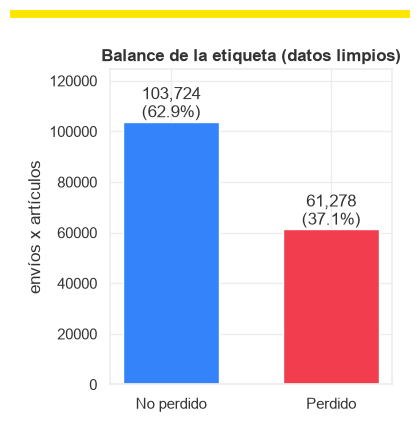

In [16]:
fig, ax = plt.subplots(figsize=(4, 4.2))
counts = clean[LABEL].value_counts().sort_index()
ax.bar(["No perdido", "Perdido"], counts.values, color=[COLOR_NOT_LOST, COLOR_LOST], width=0.6)
ax.set_title("Balance de la etiqueta (datos limpios)")
ax.set_ylabel("envíos x artículos")
ax.set_ylim(0, counts.max() * 1.2)
for i, v in enumerate(counts.values):
    ax.text(i, v, f"{v:,}\n({v / counts.sum():.1%})", ha="center", va="bottom")
finish_figure(fig, "balance_etiqueta")

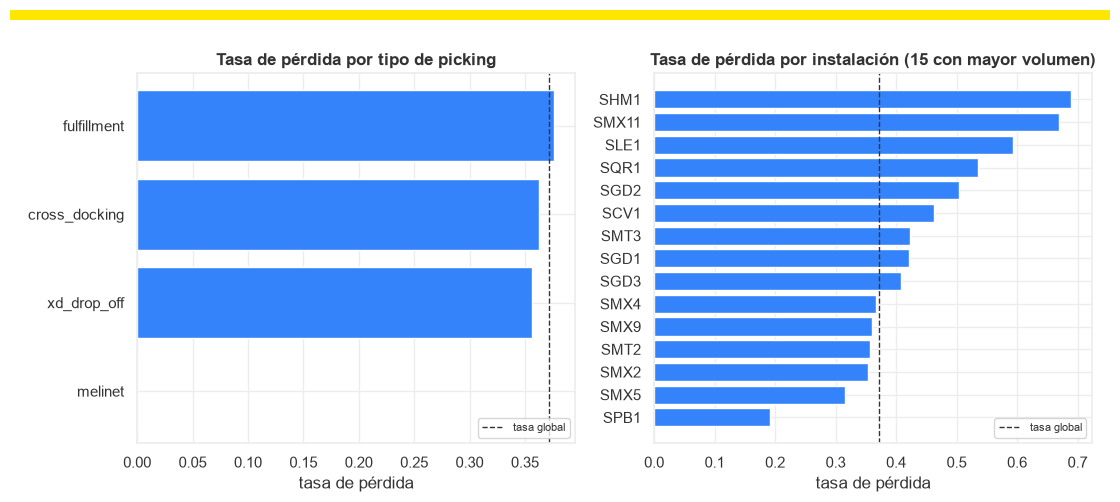

In [17]:
def lost_rate_bar(ax, series, title, top_n=None):
    rate = clean.groupby(series, observed=True)[LABEL].mean().sort_values(ascending=False)
    if top_n:
        rate = rate.head(top_n)
    ax.barh(rate.index.astype(str)[::-1], rate.values[::-1], color=COLOR_SEQUENTIAL)
    ax.set_title(title)
    ax.set_xlabel("tasa de pérdida")
    ax.axvline(clean[LABEL].mean(), color=COLOR_REFERENCE, linestyle="--", linewidth=1, label="tasa global")
    ax.legend(loc="lower right", fontsize=8)


fig, axes = plt.subplots(1, 2, figsize=(11, 5))
lost_rate_bar(axes[0], clean["PICKING_TYPE"], "Tasa de pérdida por tipo de picking")

top_facilities = clean["SHP_LG_FACILITY_ID"].value_counts().head(15).index
facility_rate = (
    clean[clean["SHP_LG_FACILITY_ID"].isin(top_facilities)]
    .groupby("SHP_LG_FACILITY_ID", observed=True)[LABEL]
    .mean()
    .sort_values(ascending=False)
)
axes[1].barh(facility_rate.index.astype(str)[::-1], facility_rate.values[::-1], color=COLOR_SEQUENTIAL)
axes[1].axvline(clean[LABEL].mean(), color=COLOR_REFERENCE, linestyle="--", linewidth=1, label="tasa global")
axes[1].set_title("Tasa de pérdida por instalación (15 con mayor volumen)")
axes[1].set_xlabel("tasa de pérdida")
axes[1].legend(loc="lower right", fontsize=8)
finish_figure(fig, "tasa_perdida_picking_instalacion")

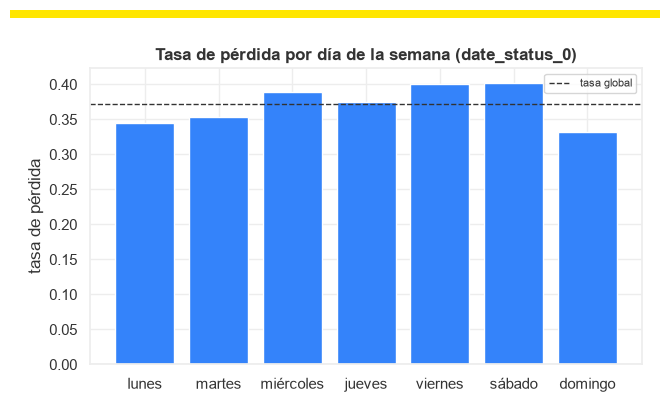

In [18]:
fig, ax = plt.subplots(figsize=(6.5, 4))
rate_by_dow = clean.groupby("day_of_week", observed=True)[LABEL].mean()
ax.bar(rate_by_dow.index.astype(str), rate_by_dow.values, color=COLOR_SEQUENTIAL)
ax.axhline(clean[LABEL].mean(), color=COLOR_REFERENCE, linestyle="--", linewidth=1, label="tasa global")
ax.set_title("Tasa de pérdida por día de la semana (date_status_0)")
ax.set_ylabel("tasa de pérdida")
ax.legend(fontsize=8)
finish_figure(fig, "tasa_perdida_dia_semana")

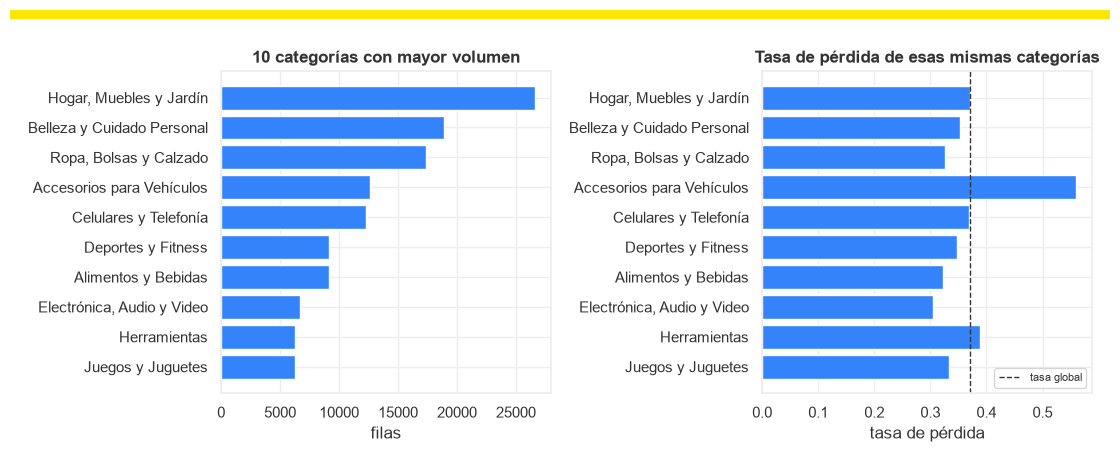

In [19]:
top_categories = clean["ORD_CATEGORY_NAME_L1"].value_counts().head(10)
rate_top_categories = clean.groupby("ORD_CATEGORY_NAME_L1", observed=True)[LABEL].mean().loc[top_categories.index]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].barh(top_categories.index.astype(str)[::-1], top_categories.values[::-1], color=COLOR_SEQUENTIAL)
axes[0].set_title("10 categorías con mayor volumen")
axes[0].set_xlabel("filas")
axes[1].barh(rate_top_categories.index.astype(str)[::-1], rate_top_categories.values[::-1], color=COLOR_SEQUENTIAL)
axes[1].axvline(clean[LABEL].mean(), color=COLOR_REFERENCE, linestyle="--", linewidth=1, label="tasa global")
axes[1].set_title("Tasa de pérdida de esas mismas categorías")
axes[1].set_xlabel("tasa de pérdida")
axes[1].legend(loc="lower right", fontsize=8)
finish_figure(fig, "categorias_volumen_tasa")

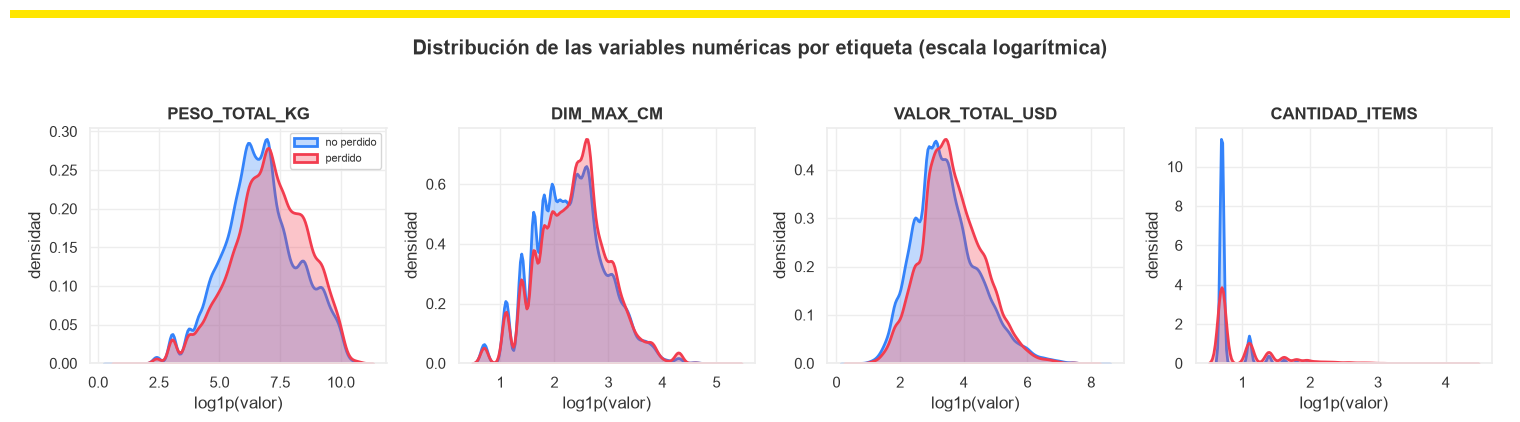

In [20]:
numeric_to_plot = ["PESO_TOTAL_KG", "DIM_MAX_CM", "VALOR_TOTAL_USD", "CANTIDAD_ITEMS"]
fig, axes = plt.subplots(1, len(numeric_to_plot), figsize=(15, 4.2))
for ax, column in zip(axes, numeric_to_plot):
    for label_value, color, name in [(0, COLOR_NOT_LOST, "no perdido"), (1, COLOR_LOST, "perdido")]:
        values = clean.loc[clean[LABEL] == label_value, column]
        values = values[values > 0]
        sns.kdeplot(np.log1p(values), ax=ax, color=color, label=name, fill=True, alpha=0.3, linewidth=2)
    ax.set_title(column)
    ax.set_xlabel("log1p(valor)")
    ax.set_ylabel("densidad")
axes[0].legend(fontsize=8)
fig.suptitle("Distribución de las variables numéricas por etiqueta (escala logarítmica)", y=0.93, fontweight="bold")
finish_figure(fig, "distribuciones_numericas", top=0.9)

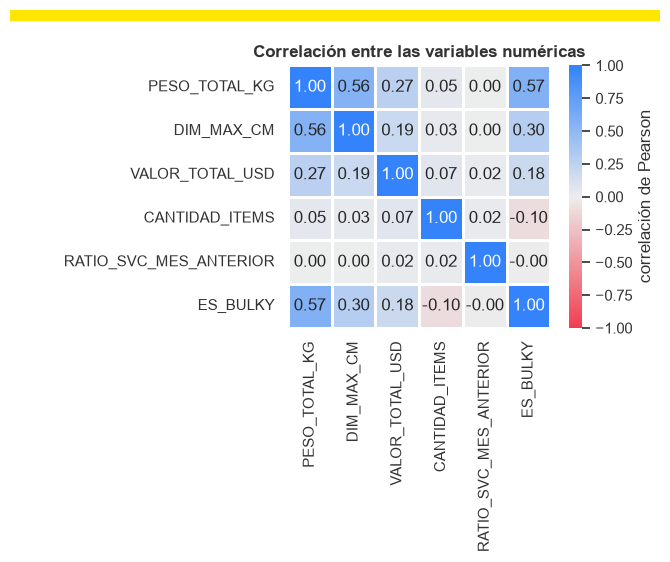

In [21]:
numeric_corr_columns = NUMERIC_FEATURES
correlation = clean[numeric_corr_columns].astype(float).corr()

fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(
    correlation,
    ax=ax,
    cmap=DIVERGING_CMAP,
    vmin=-1,
    vmax=1,
    center=0,
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=2,
    linecolor=ML_SURFACE,
    cbar_kws={"label": "correlación de Pearson"},
)
ax.set_title("Correlación entre las variables numéricas")
finish_figure(fig, "correlacion_numericas")

## 5. Partición temporal entrenamiento / validación / prueba

La partición es **temporal**: se entrena con los meses más antiguos y se
valida y se prueba con los más recientes, de modo que ninguna información
futura influye en el entrenamiento. Es la pregunta que importa en operación:
¿qué tan bien ordena el modelo envíos que todavía no existían cuando se
entrenó?

Los meses de cada partición se calculan a partir de los datos, no se fijan a
mano: la prueba toma los meses más recientes de `date_status_0` hasta cubrir
al menos `MIN_HOLDOUT_SHARE` de las filas, la validación toma los meses
inmediatamente anteriores con el mismo criterio y el resto queda para
entrenamiento. El mes se usa solo para partir; no es una variable del modelo
(hecho 5).

La granularidad por artículo (hecho 9) sigue exigiendo que ningún envío quede
repartido entre particiones. Todas las filas de un envío comparten el mismo
`date_status_0`, así que la partición temporal lo cumple por construcción; los
`assert` lo verifican de todas formas.

In [22]:
def take_latest_months(available, month_share, min_share):
    """Retira de `available` los meses más recientes hasta cubrir al menos `min_share` de las filas."""
    taken = []
    while available and month_share.loc[taken].sum() < min_share:
        taken.insert(0, available.pop())
    return taken


# `preprocess` conserva el índice de `raw`, así que el mes se recupera sin
# agregar la fecha a la tabla del modelo.
split_month = raw.loc[clean.index, DATE_COLUMN].dt.to_period("M")
month_share = split_month.value_counts(normalize=True).sort_index()

available_months = list(month_share.index)
test_months = take_latest_months(available_months, month_share, MIN_HOLDOUT_SHARE)
val_months = take_latest_months(available_months, month_share, MIN_HOLDOUT_SHARE)
train_months = available_months
assert train_months and val_months and test_months

train = clean.loc[split_month.isin(train_months)]
val = clean.loc[split_month.isin(val_months)]
test = clean.loc[split_month.isin(test_months)]
assert len(train) + len(val) + len(test) == len(clean)
assert max(train_months) < min(val_months) and max(val_months) < min(test_months)

train_groups, val_groups, test_groups = set(train[GROUP]), set(val[GROUP]), set(test[GROUP])
assert not (train_groups & val_groups)
assert not (train_groups & test_groups)
assert not (val_groups & test_groups)

split_summary = pd.DataFrame(
    [
        {
            "particion": name,
            "meses": f"{min(months)} a {max(months)}",
            "filas": len(part),
            "proporcion_filas": len(part) / len(clean),
            "envios": part[GROUP].nunique(),
            "tasa_positivos": part[LABEL].mean(),
        }
        for name, part, months in [
            ("entrenamiento", train, train_months),
            ("validación", val, val_months),
            ("prueba", test, test_months),
        ]
    ]
).set_index("particion")

train = train.drop(columns=GROUP)
val = val.drop(columns=GROUP)
test = test.drop(columns=GROUP)
split_summary.round(3)

,meses,filas,proporcion_filas,envios,tasa_positivos
particion,,,,,
entrenamiento,2025-09 a 2026-01,125082,0.758,112303,0.390
validación,2026-02 a 2026-02,18831,0.114,17297,0.316
prueba,2026-03 a 2026-03,21089,0.128,19506,0.312


## 6. Entrenamiento

`TabularPredictor` es el punto de entrada de AutoML de AutoGluon: por defecto
entrena y combina varias familias de modelos (árboles con *gradient boosting*,
bosques aleatorios, redes neuronales, etc.). Aquí el objetivo es
específicamente una red neuronal artificial (RNA), así que `hyperparameters` se
restringe a los dos motores de redes neuronales de AutoGluon: `NN_TORCH` (un
MLP tabular en PyTorch) y `FASTAI` (el modelo tabular de fastai). No se entrena
ningún árbol.

Se usa `eval_metric="average_precision"` en lugar de la exactitud
(*accuracy*): la etiqueta está desbalanceada (alrededor de un tercio de
positivos tras la limpieza, ~24% en los datos crudos), de modo que un modelo
que siempre predijera "no perdido" ya obtendría cerca de dos tercios de
exactitud sin servir para nada. La precisión promedio (el área bajo la curva
de precisión-exhaustividad, PR-AUC) premia ordenar bien la clase positiva, que
es lo que realmente importa en una puntuación de riesgo.

`tuning_data=val` pasa de forma explícita la partición de validación temporal,
en lugar de dejar que AutoGluon separe su propia reserva interna a partir de
`train`: esa reserva interna se tomaría al azar, mezclaría meses y no
respetaría el orden temporal que la sección 5 establece.

El entrenamiento se repite con `N_SEEDS` semillas. La partición y el conjunto
de prueba son los mismos en todas las corridas; lo único que cambia es la
semilla de las redes (inicialización de pesos, orden de los lotes, *dropout*).
Así la sección 7 puede reportar media y dispersión, y distinguir una diferencia
real de desempeño de simple ruido de entrenamiento. `TIME_LIMIT` se aplica a
cada semilla por separado.

In [23]:
from autogluon.tabular import TabularPredictor

predictors = {}
fit_seconds = {}
for seed in SEEDS:
    started = time.perf_counter()
    predictors[seed] = TabularPredictor(
        label=LABEL,
        problem_type="binary",
        eval_metric="average_precision",
        path=f"{MODEL_DIR}/seed_{seed}",
        verbosity=1,
    ).fit(
        train,
        tuning_data=val,
        # Cada motor nombra distinto su semilla.
        hyperparameters={"NN_TORCH": {"seed_value": seed}, "FASTAI": {"random_seed": seed}},
        time_limit=TIME_LIMIT,
    )
    fit_seconds[seed] = time.perf_counter() - started
    print(f"semilla {seed}: entrenamiento en {fit_seconds[seed]:.0f} s")

Metric average_precision is not supported by this model - using log_loss instead


Metric average_precision is not supported by this model - using log_loss instead


semilla 42: entrenamiento en 80 s


Metric average_precision is not supported by this model - using log_loss instead


semilla 43: entrenamiento en 90 s


Metric average_precision is not supported by this model - using log_loss instead


semilla 44: entrenamiento en 76 s


Metric average_precision is not supported by this model - using log_loss instead


semilla 45: entrenamiento en 81 s


semilla 46: entrenamiento en 84 s


## 7. Evaluación sobre el conjunto de prueba reservado

`test` nunca se vio durante el entrenamiento ni durante la selección de modelos
(quedó fuera tanto de `train` como del `tuning_data` usado para la detención
temprana y la selección de modelos), y corresponde a meses posteriores a los
de las otras dos particiones.

Primero se evalúa cada semilla con las mismas métricas: PR-AUC y ROC-AUC (que
no dependen de un umbral), exhaustividad (*recall*), precisión y F1 de la clase
"perdido" con umbral 0,5, la tasa de falsos positivos con ese mismo umbral, y
las métricas de priorización `recall_en_K` y
`precision_en_K`. Estas últimas responden la pregunta operativa: si el equipo
solo puede revisar el K% de los envíos con mayor puntaje, ¿qué proporción de
las pérdidas reales queda dentro de ese grupo (`recall_en_K`) y qué proporción
de lo revisado era realmente una pérdida (`precision_en_K`)? La tabla cierra
con la media y la desviación estándar entre semillas.

In [24]:
y_true = test[LABEL].to_numpy()


def ranking_at_k(y_true, scores, fractions):
    """Precisión y exhaustividad al revisar solo la fracción de casos con mayor puntaje."""
    order = np.argsort(-np.asarray(scores), kind="stable")
    sorted_true = np.asarray(y_true)[order]
    prevalence = sorted_true.mean()
    rows = []
    for fraction in fractions:
        k = max(1, int(round(fraction * len(sorted_true))))
        hits = sorted_true[:k].sum()
        rows.append({
            "fraccion_revisada": fraction,
            "casos_revisados": k,
            "precision_en_k": hits / k,
            "recall_en_k": hits / sorted_true.sum(),
            # Cuántas veces mejor que revisar al azar, con la prevalencia de la muestra.
            "mejora_sobre_azar": (hits / k) / prevalence,
        })
    return pd.DataFrame(rows).set_index("fraccion_revisada")


def evaluate_seed(predictor, threshold=0.5):
    scores = predictor.predict_proba(test, as_multiclass=False).to_numpy()
    predicted = (scores >= threshold).astype(int)
    metrics = {
        "pr_auc_validacion": predictor.evaluate(val, silent=True)["average_precision"],
        "pr_auc": average_precision_score(y_true, scores),
        "roc_auc": roc_auc_score(y_true, scores),
        "recall": recall_score(y_true, predicted),
        "precision": precision_score(y_true, predicted),
        "f1": f1_score(y_true, predicted),
        "tasa_falsos_positivos": ((predicted == 1) & (y_true == 0)).sum() / (y_true == 0).sum(),
    }
    for fraction, row in ranking_at_k(y_true, scores, RANKING_FRACTIONS).iterrows():
        metrics[f"recall_en_{fraction:.0%}"] = row["recall_en_k"]
        metrics[f"precision_en_{fraction:.0%}"] = row["precision_en_k"]
    return metrics


seed_metrics = pd.DataFrame({seed: evaluate_seed(predictor) for seed, predictor in predictors.items()})
seed_metrics.loc["segundos_entrenamiento"] = pd.Series(fit_seconds)
seed_metrics.columns.name = "semilla"

seed_summary = seed_metrics.copy()
seed_summary["media"] = seed_metrics.mean(axis=1)
seed_summary["desviacion"] = seed_metrics.std(axis=1)
seed_summary.round(4)

semilla,42,43,44,45,46,media,desviacion
pr_auc_validacion,0.7617,0.7643,0.7642,0.7646,0.7671,0.7644,0.0019
pr_auc,0.7503,0.7515,0.7507,0.7464,0.7489,0.7496,0.0020
roc_auc,0.8244,0.8265,0.8244,0.8209,0.8241,0.8241,0.0020
recall,0.5576,0.5324,0.5251,0.5246,0.5299,0.5339,0.0136
precision,0.7296,0.7634,0.7697,0.7581,0.7632,0.7568,0.0157
f1,0.6321,0.6273,0.6243,0.6201,0.6255,0.6259,0.0044
tasa_falsos_positivos,0.0937,0.0749,0.0713,0.0760,0.0746,0.0781,0.0089
recall_en_1%,0.0321,0.0321,0.0321,0.0321,0.0321,0.0321,0.0000
precision_en_1%,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000
recall_en_5%,0.1583,0.1577,0.1588,0.1572,0.1585,0.1581,0.0006


### Modelo de referencia

El detalle que sigue (tabla de modelos, matriz de confusión, curvas e
importancia de variables) corresponde a un solo modelo: el de la semilla con
mejor PR-AUC en **validación**. Elegirlo por su resultado en prueba sería
seleccionar el modelo con los datos reservados para evaluarlo. Sus números
deben leerse junto con la dispersión de la tabla anterior.

In [25]:
reference_seed = seed_metrics.loc["pr_auc_validacion"].idxmax()
predictor = predictors[reference_seed]
print(f"semilla de referencia: {reference_seed}")

semilla de referencia: 46


In [26]:
predictor.leaderboard(test, display=True)

                 model  score_test  score_val        eval_metric  pred_time_test  pred_time_val   fit_time  pred_time_test_marginal  pred_time_val_marginal  fit_time_marginal  stack_level  can_infer  fit_order
0  WeightedEnsemble_L2    0.748949   0.767053  average_precision        0.128197       0.104034  83.503807                 0.000660                0.001717           0.079683            2       True          3
1      NeuralNetFastAI    0.732702   0.748843  average_precision        0.080229       0.060682  56.284891                 0.080229                0.060682          56.284891            1       True          1
2       NeuralNetTorch    0.679610   0.698392  average_precision        0.047308       0.041635  27.139233                 0.047308                0.041635          27.139233            1       True          2


,model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,0.748949,0.767053,average_precision,0.128197,0.104034,83.503807,0.000660,0.001717,0.079683,2,True,3
1,NeuralNetFastAI,0.732702,0.748843,average_precision,0.080229,0.060682,56.284891,0.080229,0.060682,56.284891,1,True,1
2,NeuralNetTorch,0.679610,0.698392,average_precision,0.047308,0.041635,27.139233,0.047308,0.041635,27.139233,1,True,2


In [27]:
predictor.evaluate(test, silent=True)

{'average_precision': 0.7489489944637808,
 'accuracy': 0.8019820759637726,
 'balanced_accuracy': np.float64(0.7276727145857372),
 'mcc': 0.5121046853466956,
 'roc_auc': np.float64(0.824073587668791),
 'f1': 0.6255380200860832,
 'precision': 0.7632385120350109,
 'recall': 0.5299301124278335}

In [28]:
proba = predictor.predict_proba(test, as_multiclass=False)

roc_auc = roc_auc_score(y_true, proba)
avg_precision = average_precision_score(y_true, proba)
print(f"ROC AUC: {roc_auc:.4f}")
print(f"Precisión promedio (PR-AUC): {avg_precision:.4f}")

ROC AUC: 0.8241
Precisión promedio (PR-AUC): 0.7489


In [29]:
y_pred = (proba >= 0.5).astype(int)
print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred, target_names=["no perdido", "perdido"]))

[[13425  1082]
 [ 3094  3488]]
              precision    recall  f1-score   support

  no perdido       0.81      0.93      0.87     14507
     perdido       0.76      0.53      0.63      6582

    accuracy                           0.80     21089
   macro avg       0.79      0.73      0.75     21089
weighted avg       0.80      0.80      0.79     21089



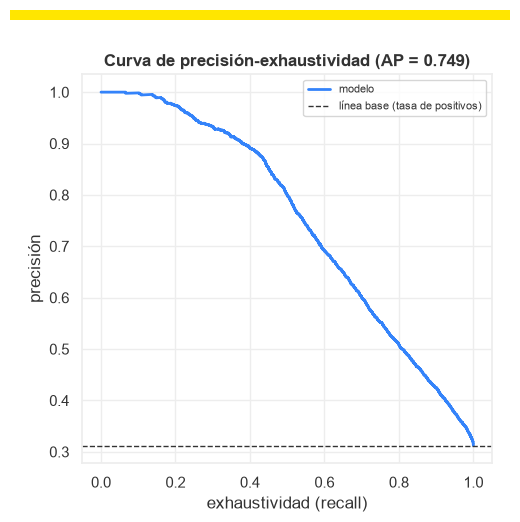

In [30]:
precision, recall, _ = precision_recall_curve(y_true, proba)
fig, ax = plt.subplots(figsize=(5, 5.2))
ax.plot(recall, precision, color=ML_BLUE, linewidth=2, label="modelo")
ax.axhline(y_true.mean(), color=COLOR_REFERENCE, linestyle="--", linewidth=1, label="línea base (tasa de positivos)")
ax.set_xlabel("exhaustividad (recall)")
ax.set_ylabel("precisión")
ax.set_title(f"Curva de precisión-exhaustividad (AP = {avg_precision:.3f})")
ax.legend(fontsize=8)
finish_figure(fig, "curva_precision_exhaustividad")

### Calidad de la priorización

RiskShip es un sistema de priorización, no solo un clasificador: su valor está
en concentrar las pérdidas reales en la fracción de envíos que un equipo con
capacidad limitada alcanza a revisar. La tabla muestra, para el modelo de
referencia, qué se obtiene al revisar solo el K% de los casos con mayor
puntaje. La curva de ganancia acumulada extiende la misma lectura a cualquier
fracción, entre dos referencias: el orden aleatorio (revisar el K% captura el
K% de las pérdidas) y el orden perfecto (todas las pérdidas primero).

Dos cuidados de lectura. El techo de `recall_en_K` lo fija la prevalencia: con
alrededor de un tercio de positivos, ni un orden perfecto captura más de ~3K%
de las pérdidas revisando el K%. Y esa prevalencia es la de la muestra, no la
de la operación real: `precision_en_K`, `recall_en_K` y `mejora_sobre_azar`
dependen de ella, así que describen qué tan bien ordena el modelo **dentro de
esta muestra** y ninguna es extrapolable tal cual a producción (el techo de
`mejora_sobre_azar`, por ejemplo, es 1/prevalencia: ~3 aquí y ~1000 en la
operación). La proyección a la prevalencia real está al final de esta sección.
Las métricas están a nivel de artículo, no de envío.

In [31]:
ranking_at_k(y_true, proba, RANKING_FRACTIONS).round(3)

,casos_revisados,precision_en_k,recall_en_k,mejora_sobre_azar
fraccion_revisada,,,,
0.01,211,1.000,0.032,3.204
0.05,1054,0.990,0.158,3.171
0.10,2109,0.933,0.299,2.990
0.20,4218,0.792,0.507,2.536


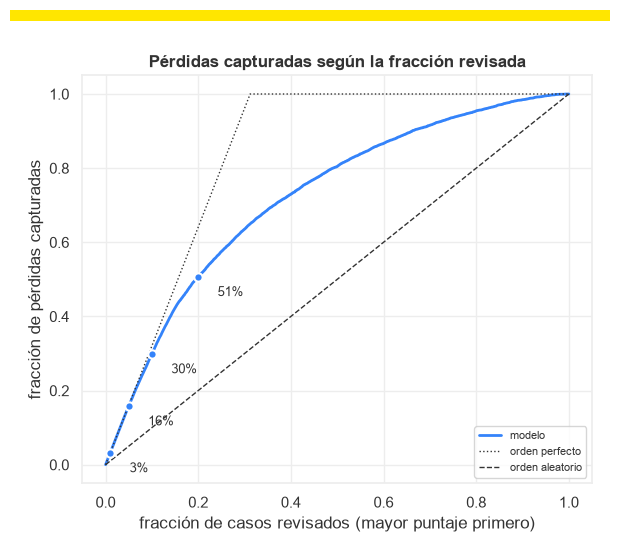

In [32]:
order = np.argsort(-proba.to_numpy(), kind="stable")
captured = np.cumsum(y_true[order]) / y_true.sum()
fraction_reviewed = np.arange(1, len(captured) + 1) / len(captured)
prevalence = y_true.mean()

fig, ax = plt.subplots(figsize=(6, 5.4))
ax.plot(fraction_reviewed, captured, color=ML_BLUE, linewidth=2, label="modelo")
ax.plot([0, prevalence, 1], [0, 1, 1], color=COLOR_REFERENCE, linestyle=":", linewidth=1, label="orden perfecto")
ax.plot([0, 1], [0, 1], color=COLOR_REFERENCE, linestyle="--", linewidth=1, label="orden aleatorio")
for fraction in RANKING_FRACTIONS:
    recall_at_fraction = captured[max(1, int(round(fraction * len(captured)))) - 1]
    ax.scatter([fraction], [recall_at_fraction], color=ML_BLUE, s=36, zorder=3, edgecolor=ML_SURFACE, linewidth=1.5)
    ax.annotate(
        f"{recall_at_fraction:.0%}", (fraction, recall_at_fraction), textcoords="offset points", xytext=(14, -14), fontsize=9
    )
ax.set_xlabel("fracción de casos revisados (mayor puntaje primero)")
ax.set_ylabel("fracción de pérdidas capturadas")
ax.set_title("Pérdidas capturadas según la fracción revisada")
ax.legend(loc="lower right", fontsize=8)
finish_figure(fig, "curva_ganancia")

### Proyección a la prevalencia real

El conjunto de datos es una muestra de **casos y controles**: conserva las
pérdidas y solo una fracción de los envíos sin pérdida, porque con una tasa
real de ~0,1 % una muestra aleatoria de cientos de miles de envíos casi no
tendría positivos. Es un diseño válido, pero cambia qué métricas se pueden
leer directamente.

Si los negativos de la muestra representan a los negativos reales, submuestrearlos
no altera la exhaustividad (proporción de pérdidas detectadas) ni la tasa de
falsos positivos (proporción de envíos sanos marcados): cada una se calcula
dentro de una sola clase. Por eso el ROC-AUC es válido tal cual. Con esas dos
tasas y la prevalencia real $\pi$ se reconstruye el escenario operativo para
cualquier umbral:

- fracción revisada $= \pi \cdot \text{exhaustividad} + (1 - \pi) \cdot \text{TFP}$
- precisión real $= \pi \cdot \text{exhaustividad}\ /\ \text{fracción revisada}$

La tabla usa como umbrales el 0,5 y los puntajes que corresponden a revisar
el K % de la muestra. `REAL_PREVALENCE` es una estimación del equipo, no un
dato medido aquí, y el supuesto de negativos representativos es justo lo que
los artefactos de extracción de la sección 2 ponen en duda: los resultados
son una proyección, no una medición.

In [33]:
def project_to_prevalence(y_true, scores, thresholds, prevalence):
    """Reconstruye el escenario operativo a partir de las dos tasas que no dependen de la prevalencia."""
    y_true, scores = np.asarray(y_true), np.asarray(scores)
    rows = []
    for name, threshold in thresholds.items():
        flagged = scores >= threshold
        recall = flagged[y_true == 1].mean()
        false_positive_rate = flagged[y_true == 0].mean()
        reviewed = prevalence * recall + (1 - prevalence) * false_positive_rate
        precision = prevalence * recall / reviewed
        rows.append({
            "umbral": name,
            "puntaje_minimo": threshold,
            "exhaustividad": recall,
            "tasa_falsos_positivos": false_positive_rate,
            "fraccion_revisada_real": reviewed,
            "precision_real": precision,
            "revisados_por_perdida": 1 / precision,
            "mejora_sobre_azar_real": precision / prevalence,
        })
    return pd.DataFrame(rows).set_index("umbral")


sorted_scores = np.sort(proba.to_numpy())[::-1]
thresholds = {"0,5": 0.5}
for fraction in RANKING_FRACTIONS:
    k = max(1, int(round(fraction * len(sorted_scores))))
    thresholds[f"{fraction:.0%} de la muestra"] = sorted_scores[k - 1]

project_to_prevalence(y_true, proba, thresholds, REAL_PREVALENCE).round(4)

,puntaje_minimo,exhaustividad,tasa_falsos_positivos,fraccion_revisada_real,precision_real,revisados_por_perdida,mejora_sobre_azar_real
umbral,,,,,,,
"0,5",0.5000,0.5299,0.0746,0.0750,0.0071,141.6036,7.0620
1% de la muestra,0.9983,0.0321,0.0000,0.0000,1.0000,1.0000,1000.0000
5% de la muestra,0.9147,0.1585,0.0008,0.0009,0.1730,5.7803,173.0017
10% de la muestra,0.7835,0.2990,0.0097,0.0100,0.0299,33.4743,29.8737
20% de la muestra,0.5307,0.5073,0.0606,0.0610,0.0083,120.3214,8.3111


In [34]:
predictor.feature_importance(test.sample(n=min(5000, len(test)), random_state=RANDOM_STATE), subsample_size=5000, num_shuffle_sets=3)

,importance,stddev,p_value,n,p99_high,p99_low
DOM_DOMAIN_ID,0.197409,0.007018,0.000210,3,0.237622,0.157197
CANTIDAD_ITEMS,0.144079,0.013248,0.001403,3,0.219994,0.068163
SHP_LG_FACILITY_ID,0.070404,0.003103,0.000324,3,0.088187,0.052621
PESO_TOTAL_KG,0.067546,0.003542,0.000458,3,0.087840,0.047252
ORD_CATEGORY_NAME_L1,0.037669,0.002486,0.000725,3,0.051917,0.023422
BRAND_NAME,0.017816,0.001197,0.000750,3,0.024672,0.010960
PICKING_TYPE,0.016673,0.000945,0.000535,3,0.022090,0.011256
DIM_MAX_CM,0.003250,0.000770,0.009090,3,0.007660,-0.001160
day_of_week,0.003092,0.000429,0.003184,3,0.005553,0.000631
VALOR_TOTAL_USD,0.001296,0.000658,0.038095,3,0.005066,-0.002474


## 8. Limitaciones y próximos pasos

- La muestra es de casos y controles: sobrerrepresenta las pérdidas a
  propósito (alrededor de un tercio de positivos frente a ~0,1 % en la
  operación). Ese diseño es válido; lo que introdujo artefactos fue que las dos
  clases se extrajeron por caminos distintos (sección 2). Las probabilidades
  predichas son una señal para ordenar por riesgo, no una probabilidad
  calibrada: para corregirlas haría falta la tasa de muestreo de los
  negativos, que no se registró.
- La proyección a la prevalencia real supone que los negativos de la muestra
  representan a los reales y usa una prevalencia estimada, no medida.
- Una nueva extracción debería usar una sola consulta para ambas clases (misma
  población, filtros, tablas y ventana de fechas de creación), submuestrear
  solo los negativos al azar con una tasa registrada, incluir únicamente
  envíos con la etiqueta ya madura, tomar los atributos como estaban al crear
  el envío y muestrear por envío, no por artículo.
- La partición es temporal, pero la ventana útil es corta: validación y prueba
  cubren cada una alrededor de un mes. El resultado describe qué tan bien se
  generaliza al mes siguiente, no a lo largo de un año con estacionalidad.
- La tasa de pérdida cambia de un mes a otro dentro de la propia ventana de
  entrenamiento, en parte por cómo se extrajeron los datos. El modelo no
  recibe ninguna fecha absoluta para no aprender ese artefacto, pero la
  composición del entrenamiento sigue reflejándolo.
- La regla de madurez (`MATURITY_RATIO`) solo descarta meses finales con una
  tasa de pérdida claramente anómala. Un mes reciente apenas inmaduro pasaría
  el filtro y subestimaría levemente los positivos del conjunto de prueba.
- Las semillas varían solo el entrenamiento de las redes, no la partición: la
  dispersión reportada mide el ruido de entrenamiento, no la sensibilidad a la
  ventana temporal elegida.
- Se usan los hiperparámetros por defecto de AutoGluon para ambas redes; no se
  exploran de forma explícita capas, neuronas, activación ni regularización.
- Las filas están a nivel de artículo, no de envío; un envío con muchos
  artículos aporta muchas filas correlacionadas a las estadísticas de una
  partición y a las métricas de priorización.
- `preprocess` está escrita como una única función reutilizable precisamente
  para poder trasladarla a un script de inferencia independiente sin reescribir
  la lógica de limpieza.
- `LG_REGION` se descartó por completo en lugar de repararse en esta pasada. Un
  mapeo instalación -> región canónica (construido de forma independiente de
  la etiqueta, por ejemplo a partir de una única fuente confiable por
  instalación) podría recuperar la región como una variable segura más
  adelante; mientras tanto, `SHP_LG_FACILITY_ID` ya aporta la señal
  geográfica.